In [2]:
import numpy as np
import bayesflow as bf
import keras
from pathlib import Path

import pickle
import pandas as pd
import matplotlib.pyplot as plt
from benchmark.examples.gaussian.analysis import summry_diagnostic as sd
from benchmark.examples.gaussian.analysis import summry_diagnostic as sd
from benchmark.examples.gaussian.analytic.analytic import GaussianAnalytical
from benchmark.examples.gaussian.npe.estimation import MarginalLikelihoodEstimator


INFO:jax._src.xla_bridge:Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/anaconda3/envs/benchmark2/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file), '/usr/local/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache)
INFO:bayesflow:Using backend 'jax'


In [3]:
from tqdm.auto import tqdm as original_tqdm
import bayesflow.approximators.helpers.samplers as bf_samplers
import bayesflow.approximators.helpers.conditions as bf_conditions

def quiet_tqdm(*args, **kwargs):
    kwargs["disable"] = True
    return original_tqdm(*args, **kwargs)

bf_samplers.tqdm = quiet_tqdm
bf_conditions.tqdm = quiet_tqdm


In [4]:
RNG=np.random.default_rng(2025)
num_dims=20
num_obs=50
mu_prior_mean=5
mu_prior_std=1
likelihood_std=1

In [5]:
# simulator
def prior(mu=mu_prior_mean, sigma=mu_prior_std):
    mu = RNG.normal(loc=mu, scale=sigma, size=num_dims)
    return dict(mu=mu)
def likelihood(mu):
    x =RNG.normal(loc=mu, scale=likelihood_std, size=(num_obs, num_dims))
    return dict(x=x)
simulator=bf.make_simulator([prior,likelihood])

In [6]:
# adapter 
adapter = (bf.adapters.Adapter()
                        .convert_dtype("float64", "float32")
                        .rename('mu', 'inference_variables')
                        .rename('x', 'summary_variables')
                )

In [7]:
# networks
summary_net = bf.networks.DeepSet(
    summary_dim=6 * num_dims
)

inference_net = bf.networks.CouplingFlow()

In [7]:
workflow = bf.BasicWorkflow(simulator=simulator,
                                          adapter=adapter,
                                          summary_network=summary_net,
                                          inference_network=inference_net,
                                          standardize="all"
                                          )
epochs=100
batch_size=64
num_batches_per_epoch=128
learning_rate=keras.optimizers.schedules.CosineDecay(
            initial_learning_rate=1e-4, 
            decay_steps=epochs * num_batches_per_epoch
            )
workflow.approximator.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate))

In [8]:
history = workflow.fit_online(epochs=epochs,batch_size=batch_size,num_batches_per_epoch=num_batches_per_epoch)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 25.0227
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 18.0528
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 13.4423
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 10.0811
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 7.0634
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 4.8860
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 3.1742
Epoch 8/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 1.9404
Epoch 9/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 1.0432
Epoch 10/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.3278
Epoch 11/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: -0.2525
Epoch 12/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: -0.7642
Epoch 13/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: -1.4485
Epoch 14/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: -2.3101
Epoch 15/100
128/128 

INFO:bayesflow:Training completed in 5.49 minutes.


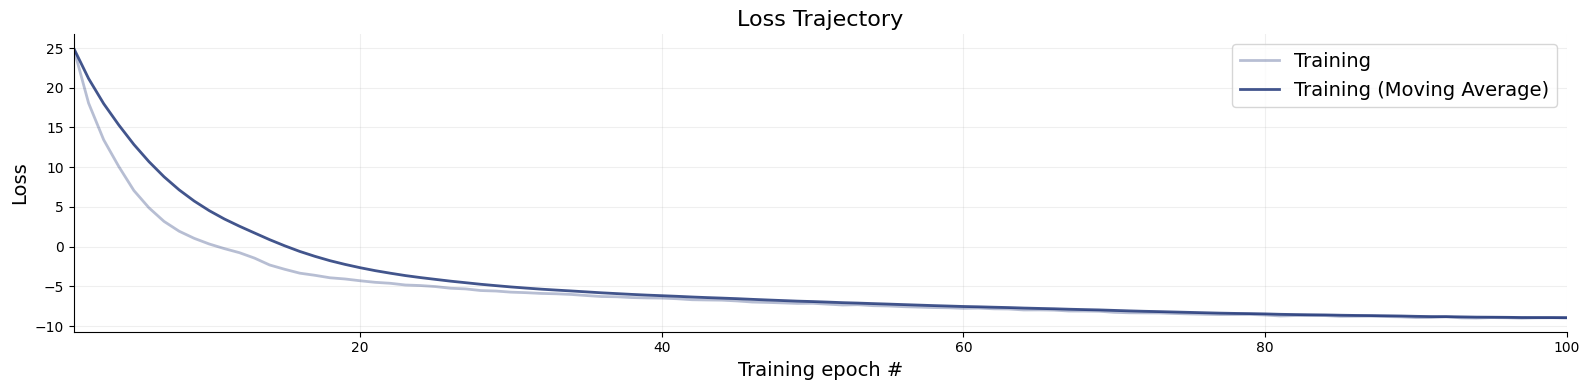

In [9]:
f=bf.diagnostics.plots.loss(history)

In [10]:
# Generate test datasets and get posterior samples and perform diagnostics
num_samples = 1000 #number of posterior samples
val_sims = simulator.sample(200) # validation data
post_draws = workflow.sample(conditions=val_sims, num_samples=num_samples)
post_draws.keys()


INFO:bayesflow:Sampling completed in 1.49 seconds.


dict_keys(['mu'])

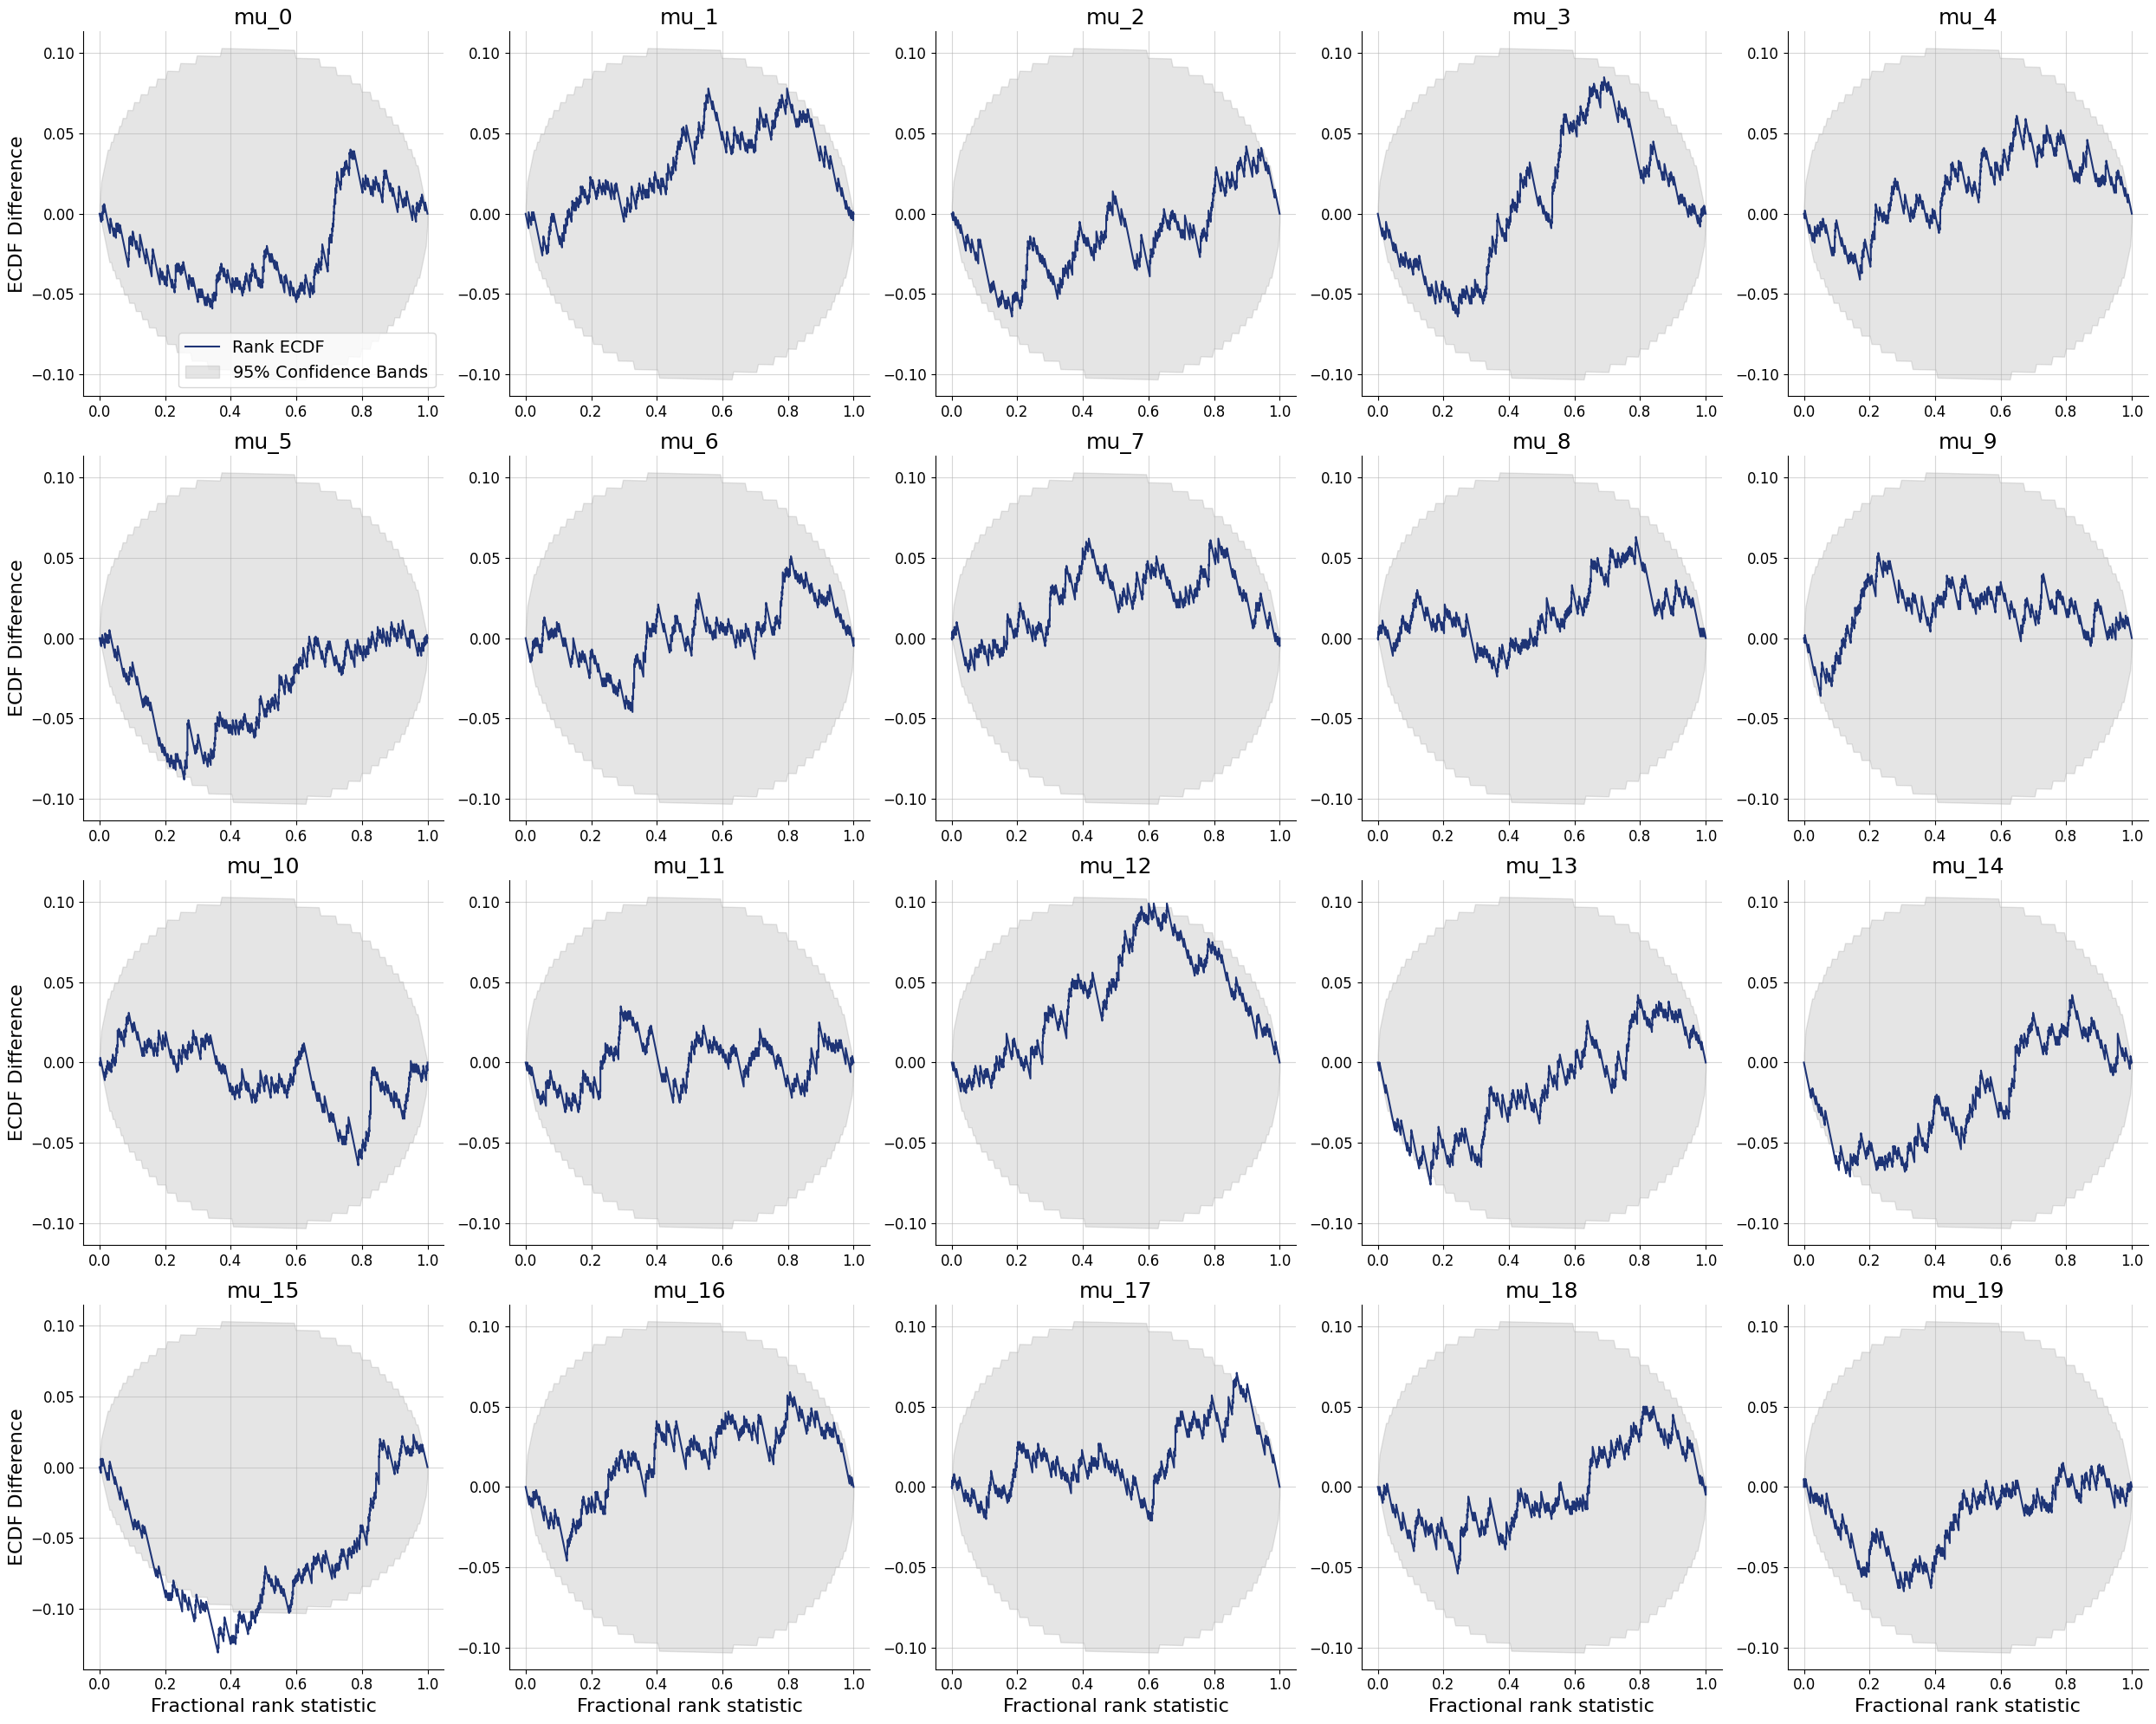

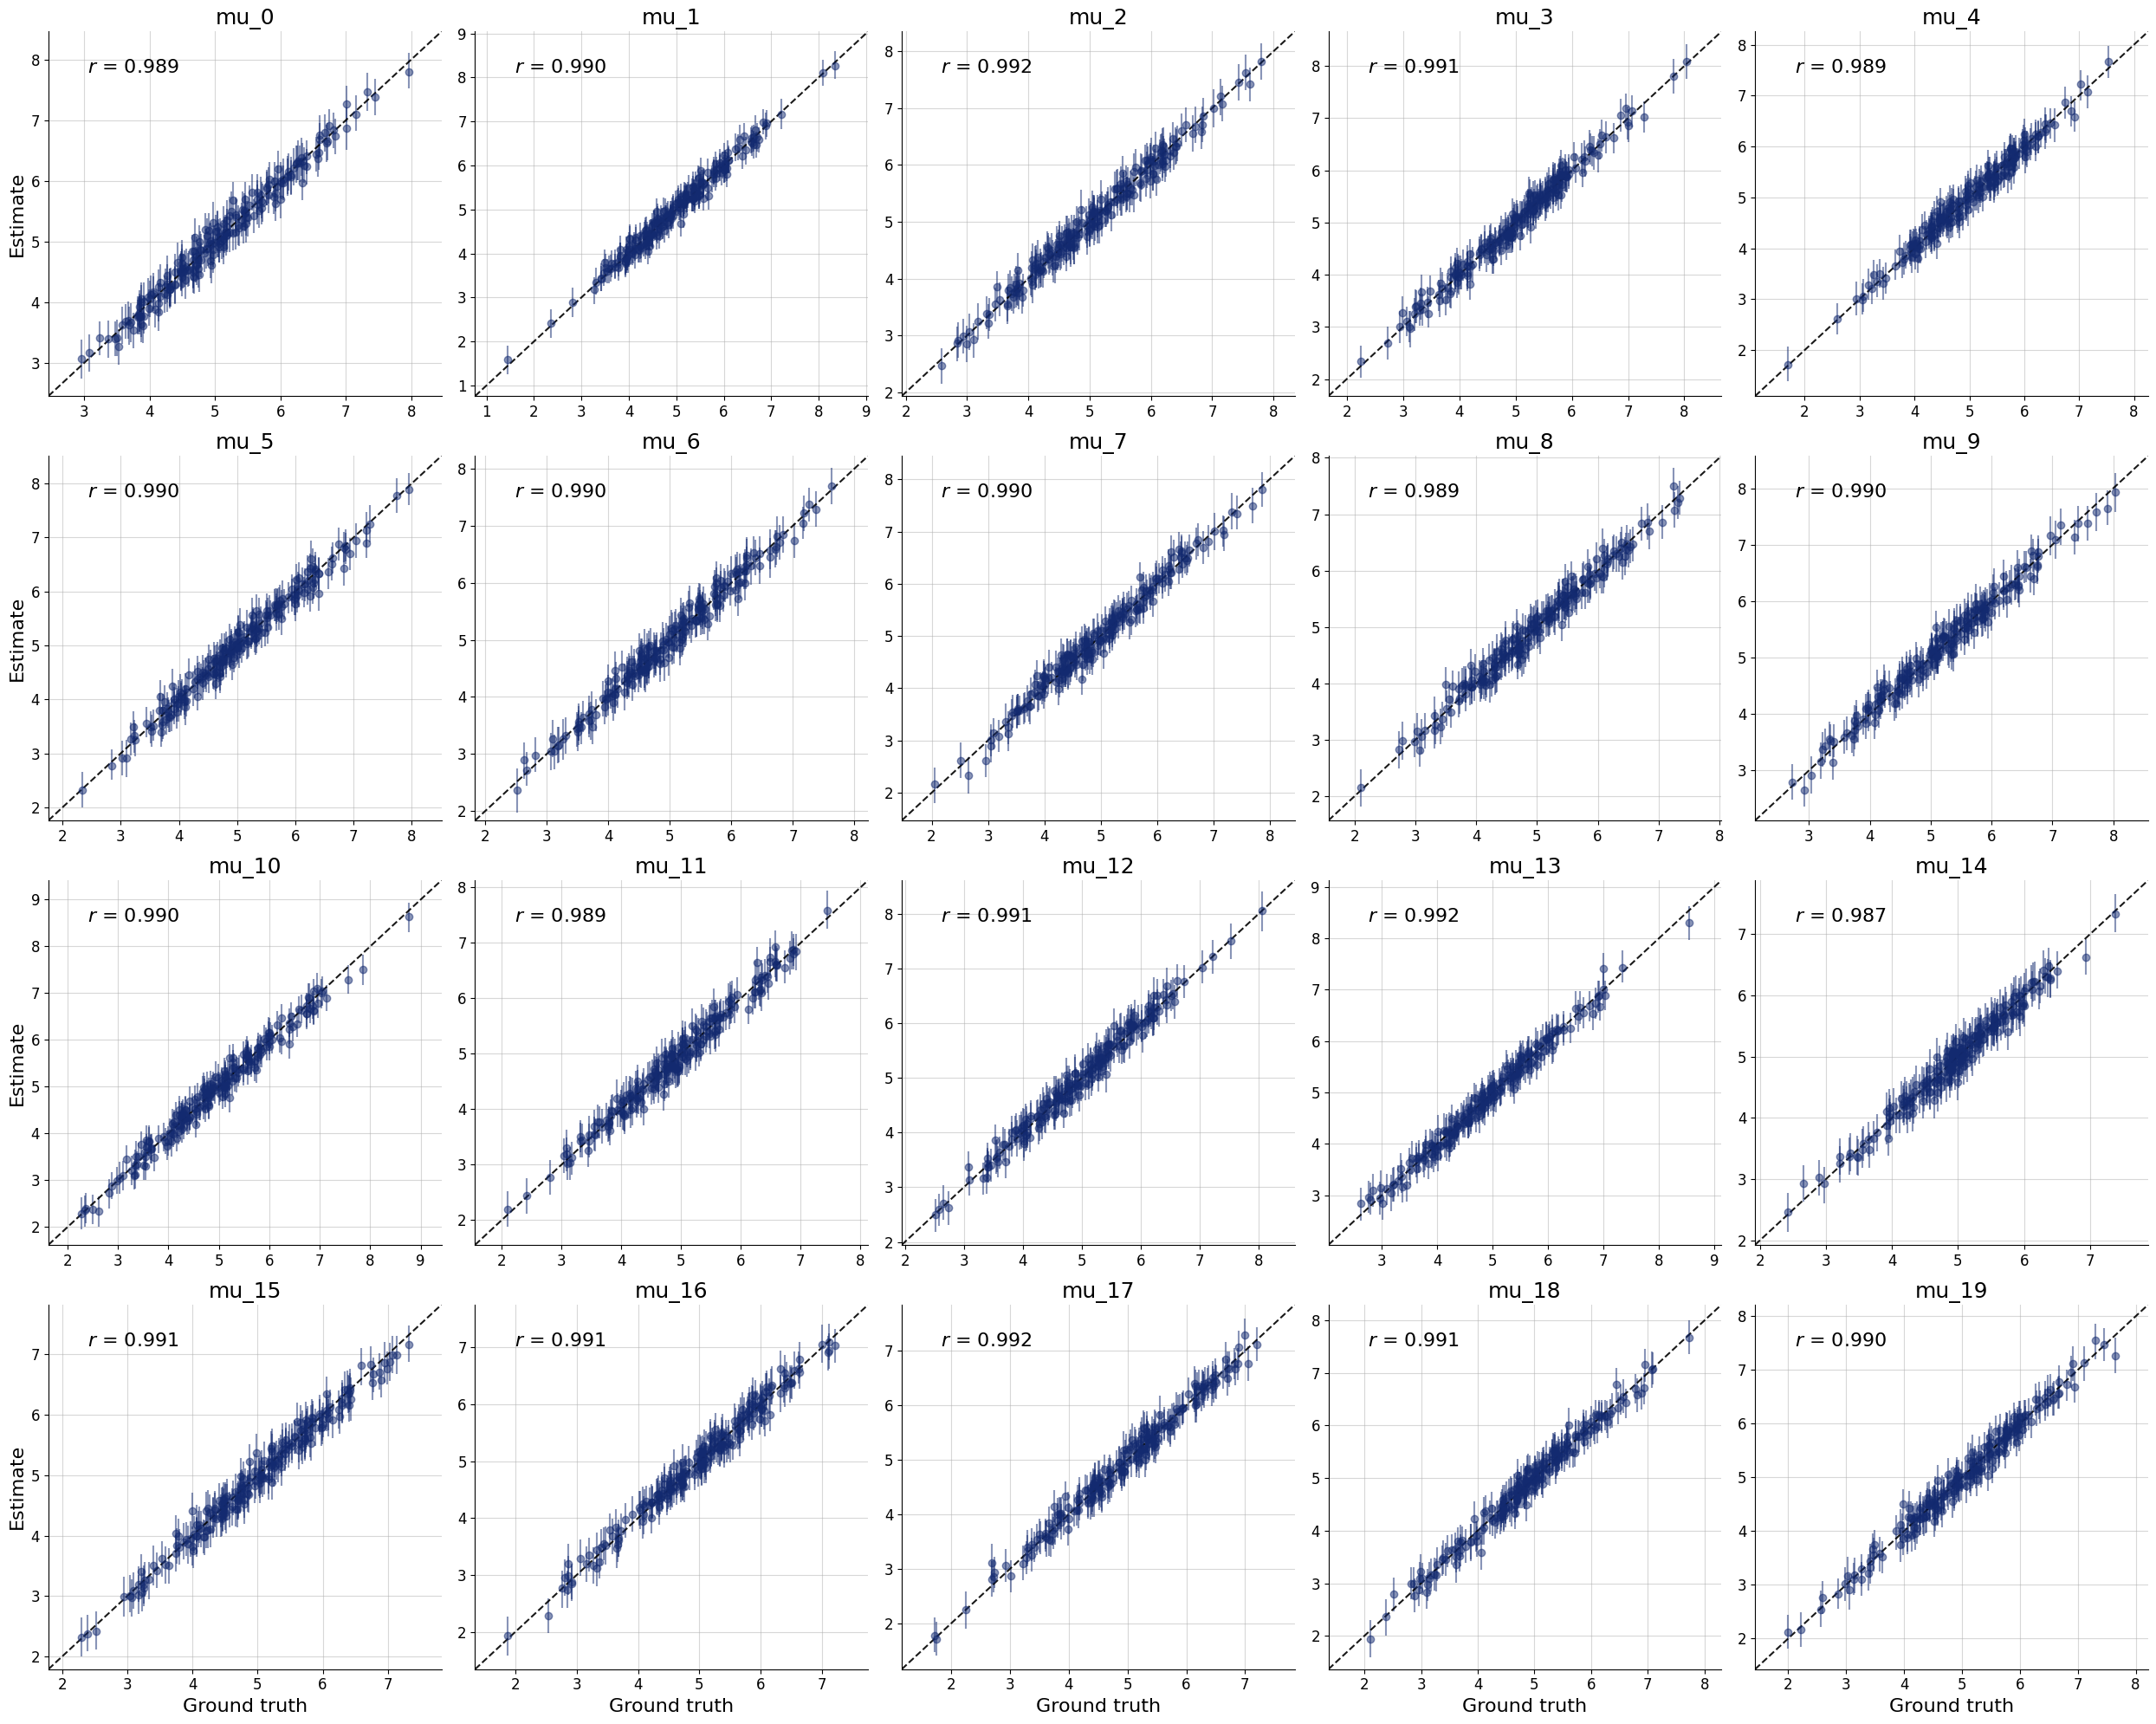

In [11]:
# f1 = bf.diagnostics.plots.calibration_histogram(post_draws, val_sims)
f2 = bf.diagnostics.plots.calibration_ecdf(post_draws, val_sims,difference=True)
f3 = bf.diagnostics.plots.recovery(post_draws, val_sims)

In [12]:
# Save the trained approximator
filepath = Path("/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian/networks") / "m2_s_20d_50n_mu5.keras"
filepath.parent.mkdir(exist_ok=True)
workflow.approximator.save(filepath=filepath)

In [8]:
# load approximator
filepath = Path("/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian/networks") / "m2_s_20d_50n_mu5.keras"
approximator = keras.saving.load_model(filepath)

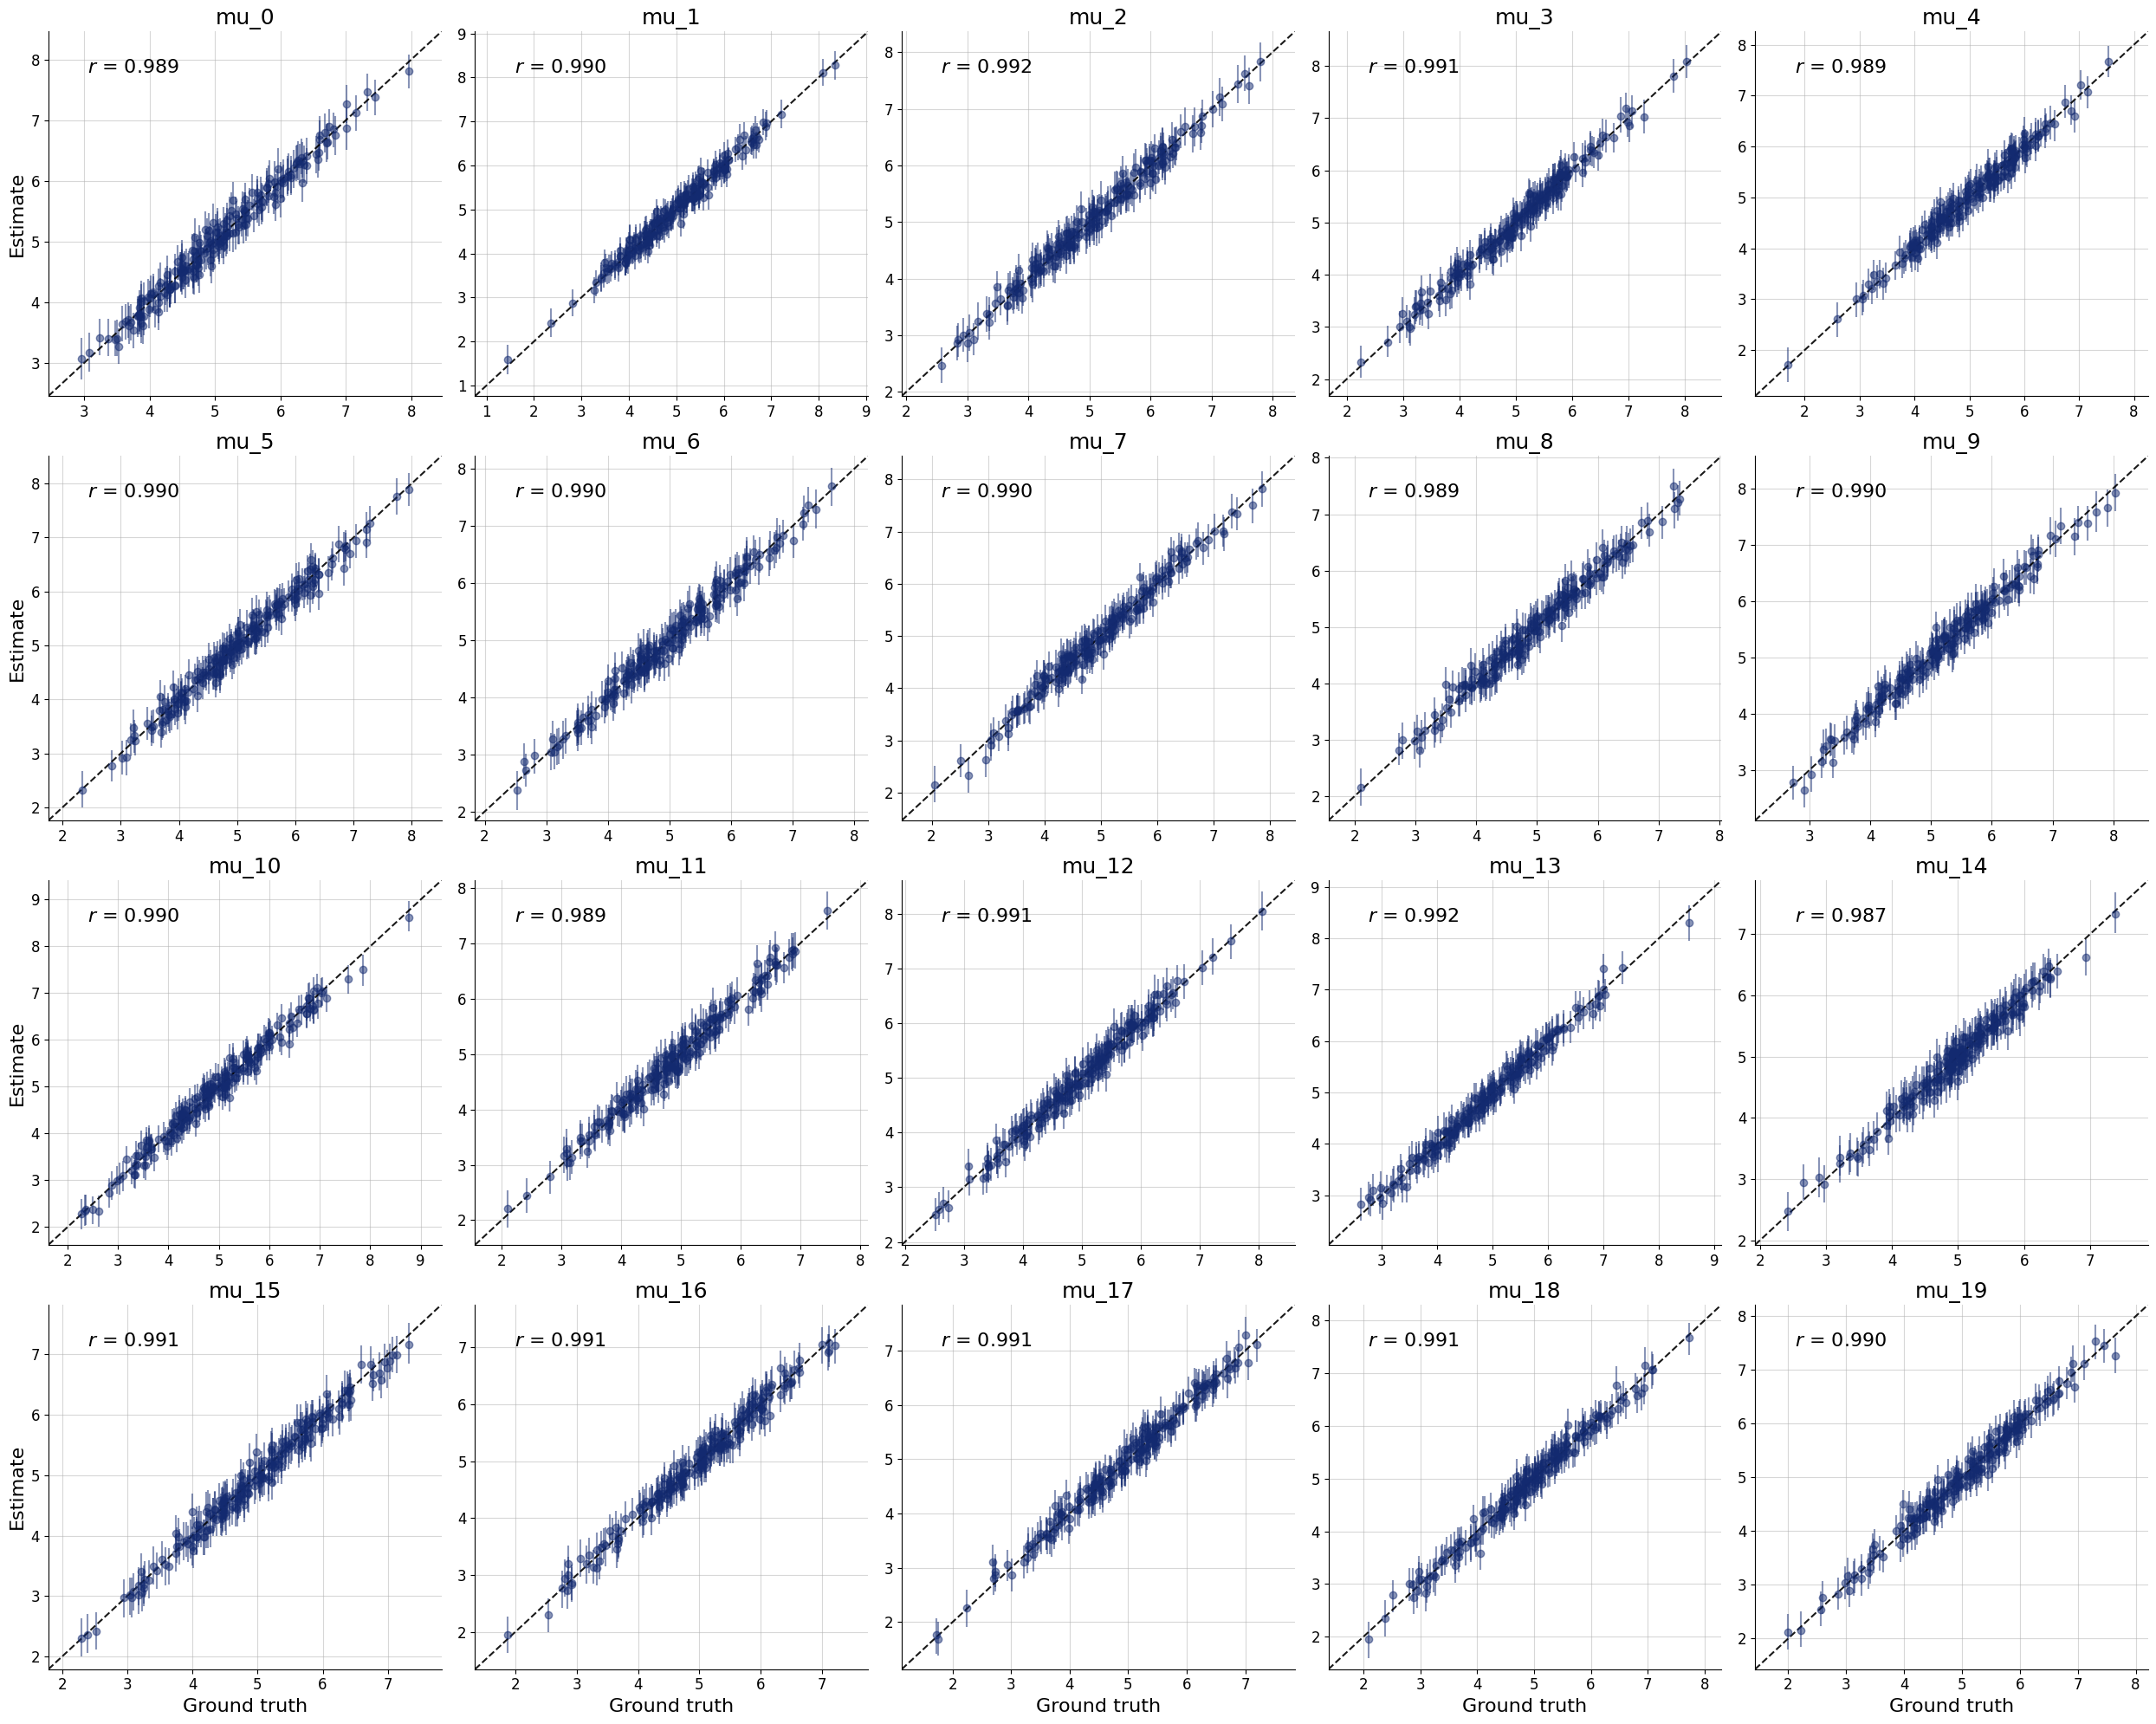

In [14]:
post_draws = approximator.sample(conditions=val_sims, num_samples=num_samples)
f3 = bf.diagnostics.plots.recovery(post_draws, val_sims)

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Reference distribution of summary-space Mahalanobis distance'}, xlabel='Mahalanobis distance $d_M$', ylabel='Density'>)

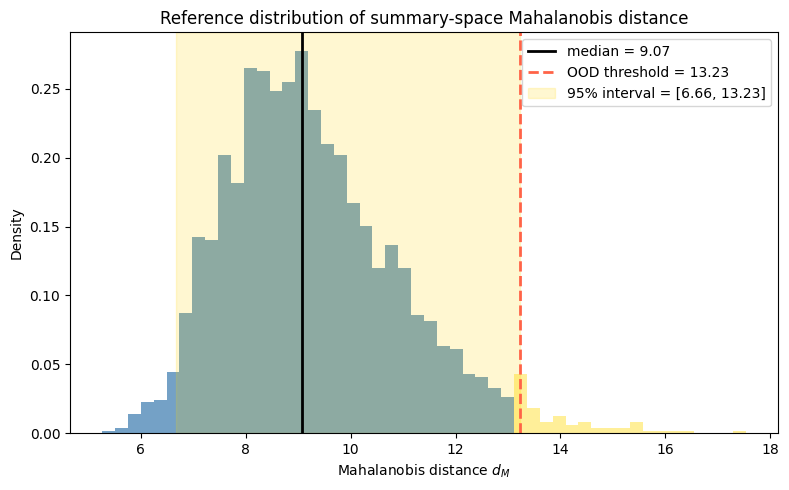

In [9]:
model_path = Path("/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian/networks/m2_s_20d_50n_mu5.keras")
dataset_dir = Path("/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian/results/datasets")

approximator = sd.load_approximator(model_path)
ref = sd.fit_reference(approximator, simulator, n_ref=2000)

sd.plot_reference(ref)


In [21]:
# df_logml = sd.collect_metric_relation(
#     approximator,
#     dataset_dir,
#     ref,
#     sources=["m1", "m2", "m3", "m4"],
#     metric_fn=sd.signed_logml_error("m1"),
#     metric_name="signed_logml_error_m1",
# )
# labels = {
#     "m1": "M1 (well_specified)",
#     "m2": "M2 (prior misspecification)",
#     "m3": "M3 (likelihood misspecification)",
#     "m4": "M4 (open_world)",
# }
# summary = sd.empirical_summary(df_logml, "signed_logml_error_m1", labels=labels)
# display(sd.format_summary(summary, "signed_logml_error_m1"))

# sd.plot_metric_relation(df_logml, summary, "signed_logml_error_m1", ref, labels=labels)

In [ ]:
# Module: simulate datasets, compute d_M, NPE logml, and analytical gold logml.
prior_means = [0.001, 0.01, 0.1, 1, 2, 4, 5,6,8, 10]
num_datasets = 50
num_logml_samples = 1000
assumed_prior_mean = mu_prior_mean  # assumed M1 prior mean; use m inside the loop for true generating prior.


def make_prior_mean(m):
    return lambda: {"mu": RNG.normal(loc=m, scale=mu_prior_std, size=num_dims)}


rows = []
for m in prior_means:
    sim_m = bf.make_simulator([make_prior_mean(m), likelihood]) # create a simulator with the specified prior mean m
    sims_m = sim_m.sample(num_datasets)
    dM = sd.mahalanobis_from_obs(approximator, sims_m, ref)
    post = approximator.sample(conditions={"x": sims_m["x"]}, num_samples=num_logml_samples)["mu"]

    for i in range(num_datasets):
        x_i = sims_m["x"][i]
        gold = GaussianAnalytical(
            obs_data=x_i,
            mu_prior_mean=assumed_prior_mean,
            mu_prior_std=mu_prior_std,
            num_dims=num_dims,
            num_obs=num_obs,
            num_samples=num_logml_samples,
            likelihood_std=likelihood_std,
            rng=RNG,
        ).log_marginal_analytical()
        npe = MarginalLikelihoodEstimator(
            approximator=approximator,
            mu=post[i],
            obs_data=x_i,
            mu_prior_mean=assumed_prior_mean,
            mu_prior_std=mu_prior_std,
            num_dims=num_dims,
            likelihood_std=likelihood_std,
            rng=RNG,
        ).log_marginal_npe()
        rows.append({"prior_mean": m, "id": i, "d_M": dM[i], "gold_logml": gold, "npe_logml": npe, "logml_error": npe - gold, "abs_logml_error": abs(npe - gold), "is_ood": dM[i] > ref["threshold"]})

prior_mean_df = pd.DataFrame(rows)
display(prior_mean_df.head())


,prior_mean,id,d_M,gold_logml,npe_logml,logml_error,abs_logml_error,is_ood
0,0.001,0,62.540196,-1695.011924,-2551.453975,-856.442050,856.442050,True
1,0.001,1,66.920577,-1638.511981,-2172.625368,-534.113387,534.113387,True
2,0.001,2,70.798506,-1701.861788,-2283.674077,-581.812289,581.812289,True
3,0.001,3,65.354190,-1713.995511,-2292.159807,-578.164296,578.164296,True
4,0.001,4,65.770527,-1653.248711,-2220.052455,-566.803744,566.803744,True


In [44]:
# Module: summarize prior-mean sweep.
prior_mean_summary = (
    prior_mean_df.groupby("prior_mean")
    .agg(
        mean_d_M=("d_M", "mean"),
        std_d_M=("d_M", "std"),
        median_d_M=("d_M", "median"),
        q025_d_M=("d_M", lambda x: np.percentile(x, 2.5)),
        q975_d_M=("d_M", lambda x: np.percentile(x, 97.5)),
        ood_rate=("is_ood", "mean"),
        median_error=("logml_error", "median"),
        median_abs_error=("abs_logml_error", "median"),
    )
    .reset_index()
)
display(prior_mean_summary)


,prior_mean,mean_d_M,std_d_M,median_d_M,q025_d_M,q975_d_M,ood_rate,median_error,median_abs_error
0,0.001,67.716447,4.634888,67.756312,60.250749,76.607280,1.00,-769.675760,769.675760
1,0.010,67.350399,5.176112,66.855494,58.486817,77.301473,1.00,-766.299941,766.299941
2,0.100,65.812980,5.554056,65.661655,57.439691,76.400860,1.00,-696.677806,696.677806
3,1.000,56.710375,4.708091,57.025149,48.140811,65.036922,1.00,-248.425007,248.425007
4,2.000,42.070318,4.718948,42.172742,33.879991,49.920409,1.00,-52.294932,52.294932
5,3.000,28.236301,4.760307,27.395863,20.275359,36.787411,1.00,-1.721050,1.721050
6,4.000,14.813959,3.214683,14.693376,8.939533,22.253548,0.74,0.005044,0.061455
7,5.000,9.326303,2.002573,8.850337,6.719456,13.247384,0.04,-0.001038,0.020588
8,8.000,37.535013,4.773609,37.219231,29.649170,47.375047,1.00,-19.399437,19.399437


/var/folders/zl/3t9l3x054fsc4vqfs0rk9zw00000gn/T/ipykernel_92716/1196508408.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(box_data, labels=[str(m) for m in prior_means], showmeans=True)


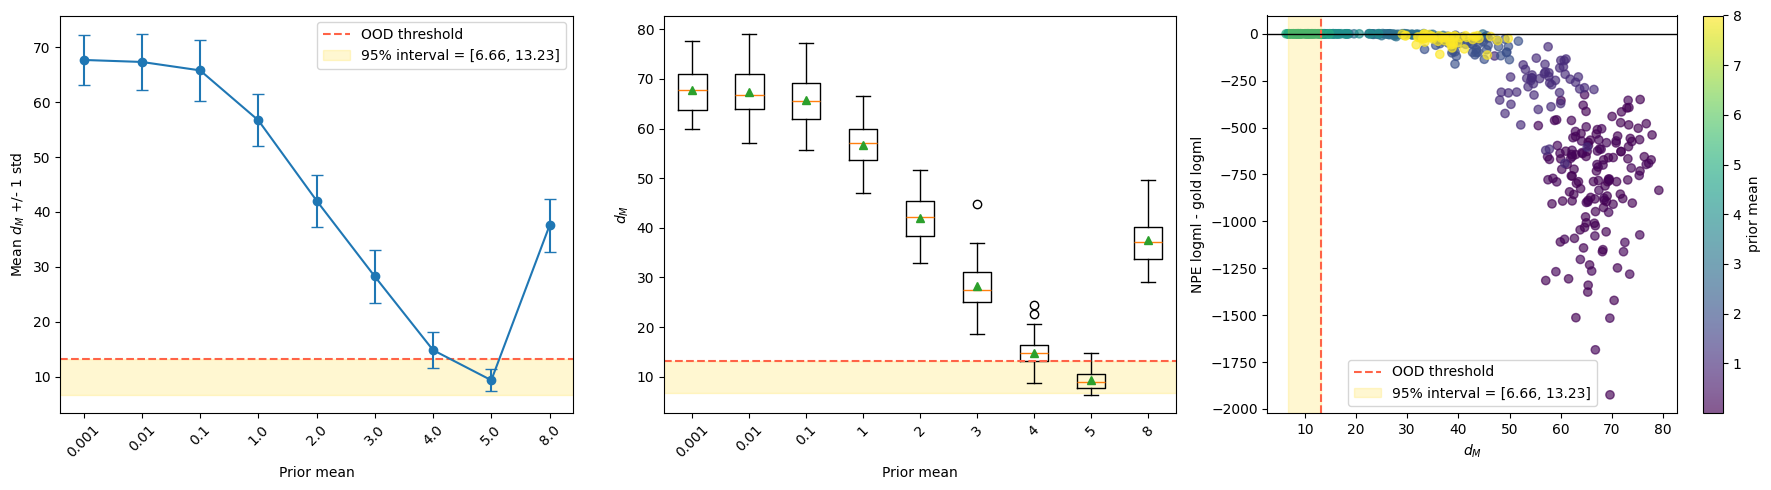

In [45]:
# Module: plot d_M distribution shift and logml-error relationship.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x_pos = np.arange(len(prior_mean_summary))
axes[0].errorbar(x_pos, prior_mean_summary["mean_d_M"], yerr=prior_mean_summary["std_d_M"], fmt="o-", capsize=4)
axes[0].axhline(ref["dm_high"], color="tomato", ls="--", label="OOD threshold")
axes[0].axhspan(ref["dm_low"], ref["dm_high"], color="gold", alpha=0.18, label=f"95% interval = [{ref['dm_low']:.2f}, {ref['dm_high']:.2f}]")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([str(v) for v in prior_mean_summary["prior_mean"]], rotation=45)
axes[0].set_xlabel("Prior mean")
axes[0].set_ylabel(r"Mean $d_M$ +/- 1 std")
axes[0].legend()

box_data = [prior_mean_df.loc[prior_mean_df["prior_mean"] == m, "d_M"] for m in prior_means]
axes[1].boxplot(box_data, labels=[str(m) for m in prior_means], showmeans=True)
axes[1].axhline(ref["dm_high"], color="tomato", ls="--")
axes[1].axhspan(ref["dm_low"], ref["dm_high"], color="gold", alpha=0.18, label=f"95% interval = [{ref['dm_low']:.2f}, {ref['dm_high']:.2f}]")
axes[1].set_xlabel("Prior mean")
axes[1].set_ylabel(r"$d_M$")
axes[1].tick_params(axis="x", rotation=45)

sc = axes[2].scatter(prior_mean_df["d_M"], prior_mean_df["logml_error"], c=prior_mean_df["prior_mean"], cmap="viridis", alpha=0.65)
axes[2].axvline(ref["dm_high"], color="tomato", ls="--", label="OOD threshold")
axes[2].axhline(0, color="black", lw=1)
axes[2].axvspan(ref["dm_low"], ref["dm_high"], color="gold", alpha=0.18, label=f"95% interval = [{ref['dm_low']:.2f}, {ref['dm_high']:.2f}]")
axes[2].set_xlabel(r"$d_M$")
axes[2].set_ylabel("NPE logml - gold logml")
axes[2].legend()
fig.colorbar(sc, ax=axes[2], label="prior mean")

plt.tight_layout()
plt.show()


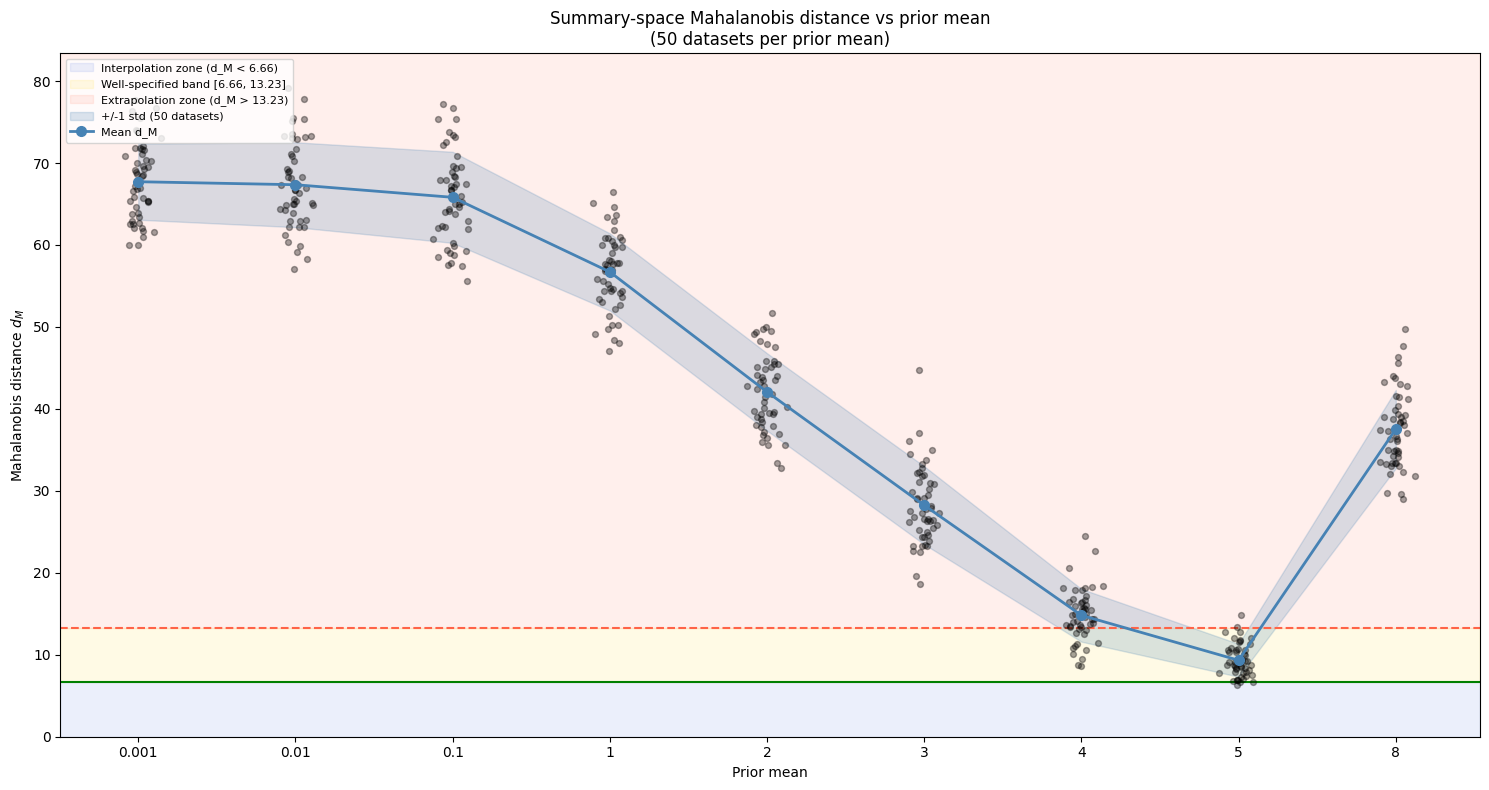

In [46]:
# Module: plot prior-mean d_M distribution with interpolation/extrapolation zones.
x = np.arange(len(prior_means))
labels_x = [str(m) for m in prior_means]

avg_dM = prior_mean_df.groupby("prior_mean", sort=False)["d_M"].mean().to_numpy()
std_dM = prior_mean_df.groupby("prior_mean", sort=False)["d_M"].std().to_numpy()
typical_radius = ref["median"]
threshold_95 = ref["dm_high"]
ymax = max((avg_dM + std_dM).max(), threshold_95) * 1.15

fig, ax = plt.subplots(figsize=(15, 8))

ax.axhspan(0, ref["dm_low"], alpha=0.10, color="royalblue", label=f"Interpolation zone (d_M < {ref["dm_low"]:.2f})")
ax.axhspan(ref["dm_low"], threshold_95, alpha=0.10, color="gold", label=f"Well-specified band [{ref["dm_low"]:.2f}, {threshold_95:.2f}]")
ax.axhspan(ref["dm_high"], ymax, alpha=0.10, color="tomato", label=f"Extrapolation zone (d_M > {ref["dm_high"]:.2f})")
ax.axhline(ref["dm_low"], color="green", lw=1.5)
ax.axhline(ref["dm_high"], color="tomato", lw=1.5, ls="--")

for i, m in enumerate(prior_means):
    vals = prior_mean_df.loc[prior_mean_df["prior_mean"] == m, "d_M"].to_numpy()
    jitter = np.random.default_rng(2026 + i).normal(0, 0.045, size=len(vals))
    ax.scatter(np.full(len(vals), i) + jitter, vals, s=18, color="black", alpha=0.35, zorder=2)

ax.fill_between(x, avg_dM - std_dM, avg_dM + std_dM, alpha=0.20, color="steelblue", label=f"+/-1 std ({num_datasets} datasets)")
ax.plot(x, avg_dM, marker="o", color="steelblue", lw=2, ms=7, label="Mean d_M", zorder=5)

ax.set_xticks(x)
ax.set_xticklabels(labels_x)
ax.set_ylim(0, ymax)
ax.set_xlabel("Prior mean")
ax.set_ylabel(r"Mahalanobis distance $d_M$")
ax.set_title(f"Summary-space Mahalanobis distance vs prior mean\n({num_datasets} datasets per prior mean)")
ax.legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.show()


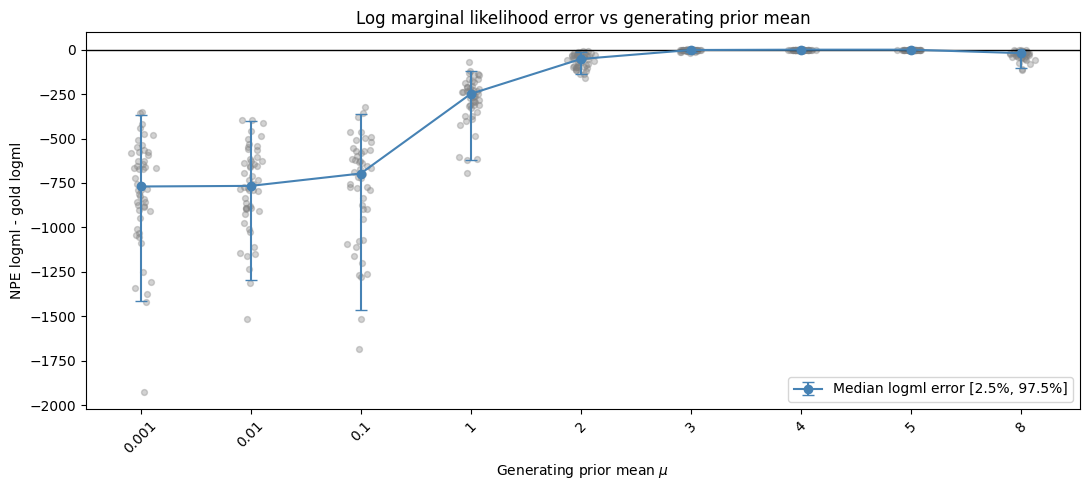

In [47]:
# Module: plot logml error vs generating prior mean.
x = np.arange(len(prior_means))
mu_labels = [str(m) for m in prior_means]

err_med = prior_mean_df.groupby("prior_mean", sort=False)["logml_error"].median().to_numpy()
err_low = prior_mean_df.groupby("prior_mean", sort=False)["logml_error"].quantile(0.025).to_numpy()
err_high = prior_mean_df.groupby("prior_mean", sort=False)["logml_error"].quantile(0.975).to_numpy()

fig, ax = plt.subplots(figsize=(11, 5))

for i, m in enumerate(prior_means):
    vals = prior_mean_df.loc[prior_mean_df["prior_mean"] == m, "logml_error"].to_numpy()
    jitter = np.random.default_rng(2026 + i).normal(0, 0.045, size=len(vals))
    ax.scatter(np.full(len(vals), i) + jitter, vals, s=18, color="gray", alpha=0.35)

ax.errorbar(
    x,
    err_med,
    yerr=[err_med - err_low, err_high - err_med],
    fmt="o-",
    capsize=4,
    color="steelblue",
    label="Median logml error [2.5%, 97.5%]",
)
ax.axhline(0, color="black", lw=1)
ax.set_xticks(x)
ax.set_xticklabels(mu_labels, rotation=45)
ax.set_xlabel(r"Generating prior mean $\mu$")
ax.set_ylabel("NPE logml - gold logml")
ax.set_title("Log marginal likelihood error vs generating prior mean")
ax.legend()

plt.tight_layout()
plt.show()


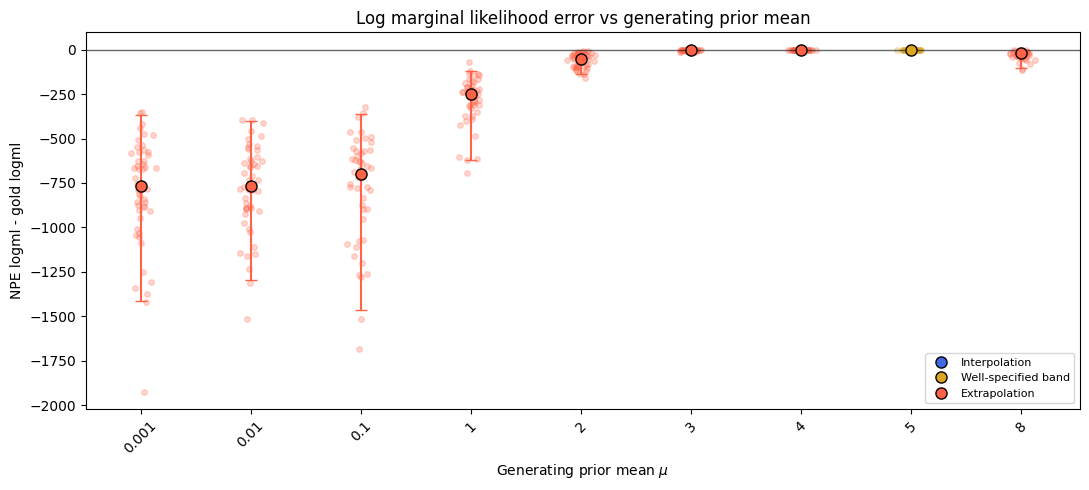

In [48]:
# Plot logml error vs generating prior mean, colored by d_M region.
x = np.arange(len(prior_means))
mu_labels = [str(m) for m in prior_means]

g = prior_mean_df.groupby("prior_mean", sort=False)

err_med = g["logml_error"].median().to_numpy()
err_low = g["logml_error"].quantile(0.025).to_numpy()
err_high = g["logml_error"].quantile(0.975).to_numpy()
dm_med = g["d_M"].median().to_numpy()

region_colors = []
for d in dm_med:
    if d < ref["dm_low"]:
        region_colors.append("royalblue")   # interpolation
    elif d <= ref["dm_high"]:
        region_colors.append("goldenrod")   # well-specified band
    else:
        region_colors.append("tomato")      # extrapolation

fig, ax = plt.subplots(figsize=(11, 5))
ax.axhline(0, color="black", lw=1, alpha=0.6)

for i, m in enumerate(prior_means):
    vals = prior_mean_df.loc[prior_mean_df["prior_mean"] == m, "logml_error"].to_numpy()
    jitter = np.random.default_rng(2026 + i).normal(0, 0.045, size=len(vals))
    ax.scatter(np.full(len(vals), i) + jitter, vals, s=16, color=region_colors[i], alpha=0.25)

for i in x:
    ax.errorbar(
        i,
        err_med[i],
        yerr=[[err_med[i] - err_low[i]], [err_high[i] - err_med[i]]],
        fmt="o",
        ms=8,
        capsize=4,
        color=region_colors[i],
        markeredgecolor="black",
    )

ax.set_xticks(x)
ax.set_xticklabels(mu_labels, rotation=45)
ax.set_xlabel(r"Generating prior mean $\mu$")
ax.set_ylabel("NPE logml - gold logml")
ax.set_title("Log marginal likelihood error vs generating prior mean")

from matplotlib.lines import Line2D
ax.legend(
    handles=[
        Line2D([0], [0], marker="o", color="w", label="Interpolation", markerfacecolor="royalblue", markeredgecolor="black", markersize=8),
        Line2D([0], [0], marker="o", color="w", label="Well-specified band", markerfacecolor="goldenrod", markeredgecolor="black", markersize=8),
        Line2D([0], [0], marker="o", color="w", label="Extrapolation", markerfacecolor="tomato", markeredgecolor="black", markersize=8),
    ],
    fontsize=8,
)

plt.tight_layout()
plt.show()

In [49]:
prior_mean_errlogml = (
    prior_mean_df
    .groupby("prior_mean", sort=False)["logml_error"]
    .median()
    .reset_index()
)

prior_mean_errlogml.columns = ["prior_mean", "median_logml_error"]

print(prior_mean_errlogml.round(3))

   prior_mean  median_logml_error
0       0.001            -769.676
1       0.010            -766.300
2       0.100            -696.678
3       1.000            -248.425
4       2.000             -52.295
5       3.000              -1.721
6       4.000               0.005
7       5.000              -0.001
8       8.000             -19.399
